TensorFlow Version: 2.11.0
✅ Model loaded.
Loading image from: sample_dataset/reference/00016.png
✅ Input image prepared. Shape: (1, 640, 640, 3)
Running inference for visualization...
Found 1 objects!


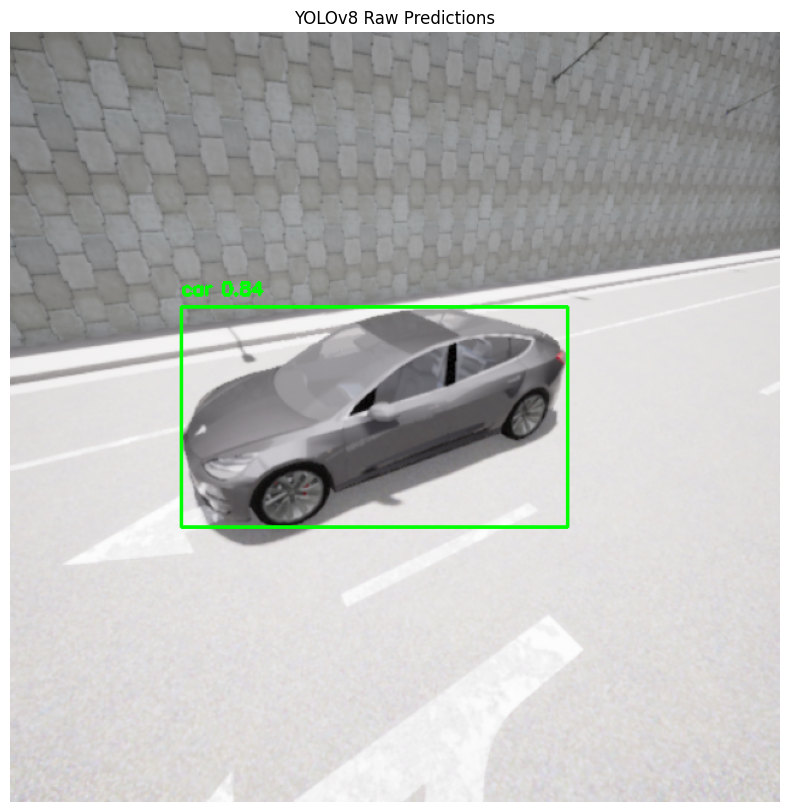

In [11]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

MODEL_PATH = 'yolov8n_saved_model'
img_path = 'sample_dataset/reference/00016.png'

# COCO Class names (subset for display)
CLASSES = {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 5: 'bus', 7: 'truck'}

print(f"TensorFlow Version: {tf.__version__}")

# 1. LOAD MODEL
loaded_model = tf.saved_model.load(MODEL_PATH)
inference_func = loaded_model.signatures['serving_default']
print("✅ Model loaded.")

# 2. LOAD & PREPROCESS IMAGE
if not os.path.exists(img_path):
    print(f"❌ Error: File not found at {img_path}")
    # Fallback noise
    initial_data = np.random.rand(1, 640, 640, 3).astype(np.float32)
    original_image_np = initial_data[0]
else:
    print(f"Loading image from: {img_path}")
    img_raw = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
    
    # Resize to 640x640 for YOLO
    img_resized = cv2.resize(img_rgb, (640, 640))
    
    # Keep a copy for drawing later (0-255 uint8)
    original_image_np = img_resized.copy()
    
    # Normalize for Model (0-1 float32)
    img_norm = img_resized.astype(np.float32) / 255.0
    initial_data = np.expand_dims(img_norm, axis=0)

# 3. CREATE TF VARIABLE
dummy_img = tf.Variable(initial_data, dtype=tf.float32)
print(f"✅ Input image prepared. Shape: {dummy_img.shape}")

# --- NEW: VISUALIZATION FUNCTION ---
def draw_predictions(raw_output, image_np, conf_threshold=0.25):
    """
    Parses raw YOLOv8 output and draws boxes on the image.
    raw_output: (1, 84, 8400)
    image_np: (640, 640, 3) uint8 image
    """
    # 1. Transpose: (1, 84, 8400) -> (1, 8400, 84)
    # Rows become anchors, columns become (x,y,w,h, class_scores...)
    preds = np.transpose(raw_output, (0, 2, 1))[0] # shape (8400, 84)
    
    boxes = []
    confidences = []
    class_ids = []
    
    h_img, w_img, _ = image_np.shape
    
    # 2. Filter by Confidence
    for i in range(len(preds)):
        row = preds[i]
        
        # The first 4 values are bbox coords (x_center, y_center, width, height)
        # The rest are class scores
        scores = row[4:]
        class_id = np.argmax(scores)
        max_score = scores[class_id]
        
        if max_score > conf_threshold:
            # YOLO outputs center_x, center_y, width, height normalized to the image size
            # (Note: Exported models sometimes output absolute pixels. We assume pixels here for 640x640)
            cx, cy, w, h = row[0], row[1], row[2], row[3]
            
            # Convert to top-left corner (x, y) for OpenCV
            x = int(cx - w/2)
            y = int(cy - h/2)
            w = int(w)
            h = int(h)
            
            boxes.append([x, y, w, h])
            confidences.append(float(max_score))
            class_ids.append(class_id)

    # 3. Non-Maximum Suppression (NMS) to remove overlapping boxes
    indices = cv2.dnn.NMSBoxes(boxes, confidences, conf_threshold, 0.45)
    
    # 4. Draw
    plot_img = image_np.copy()
    if len(indices) > 0:
        print(f"Found {len(indices)} objects!")
        for i in indices.flatten():
            box = boxes[i]
            x, y, w, h = box[0], box[1], box[2], box[3]
            label = str(CLASSES.get(class_ids[i], f"id_{class_ids[i]}"))
            conf = confidences[i]
            
            # Draw Box
            cv2.rectangle(plot_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
            # Draw Label
            cv2.putText(plot_img, f"{label} {conf:.2f}", (x, y - 10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    else:
        print("No objects found above confidence threshold.")
        
    return plot_img

# --- RUN INFERENCE & VISUALIZE ---
print("Running inference for visualization...")

# Run raw inference
# Note: We use the tensor version for prediction
image_tensor = tf.convert_to_tensor(dummy_img)
output_dict = inference_func(images=image_tensor)
raw_preds = output_dict['output_0'].numpy() # Convert to numpy for processing

# Visualize
result_img = draw_predictions(raw_preds, original_image_np)

plt.figure(figsize=(10, 10))
plt.imshow(result_img)
plt.title("YOLOv8 Raw Predictions")
plt.axis('off')
plt.show()

# --- OPTIONAL: KEEP GRADIENT CHECK ---
# (You can leave your gradient check function here if you still want to verify gradients)